<a href="https://colab.research.google.com/github/smal3iutre2/washu-5509/blob/main/HW/CSE5509_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework: Inference with CLIP

Pre-trained vision-language models (VLMs) are a cornerstone of computer vision research and engineered computer vision systems alike. To prepare you for your projects, you will implement some basic multimodal capabilities using the pretrained `openai/clip-vit-base-patch32` model from the HuggingFace.

You will implement and explore zero-shot image classification, text-to-image retrieval, composed image retrieval, and cross-modal similarity heatmaps.


In [1]:
import warnings
warnings.filterwarnings('ignore')
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import torch.nn.functional as F


In [2]:
# load the model and processor
model_id = "openai/clip-vit-base-patch32"
model = None
processor = None

def get_model():
    global model, processor #djikstra is fuminggg
    if model is None:
        from transformers import CLIPProcessor, CLIPModel
        model = CLIPModel.from_pretrained(model_id)
        processor = CLIPProcessor.from_pretrained(model_id)
    return model, processor

# pre-load it once so it doesn't take too long during execution later
get_model()


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

(CLIPModel(
   (text_model): CLIPTextTransformer(
     (embeddings): CLIPTextEmbeddings(
       (token_embedding): Embedding(49408, 512)
       (position_embedding): Embedding(77, 512)
     )
     (encoder): CLIPEncoder(
       (layers): ModuleList(
         (0-11): 12 x CLIPEncoderLayer(
           (self_attn): CLIPAttention(
             (k_proj): Linear(in_features=512, out_features=512, bias=True)
             (v_proj): Linear(in_features=512, out_features=512, bias=True)
             (q_proj): Linear(in_features=512, out_features=512, bias=True)
             (out_proj): Linear(in_features=512, out_features=512, bias=True)
           )
           (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
           (mlp): CLIPMLP(
             (activation_fn): QuickGELUActivation()
             (fc1): Linear(in_features=512, out_features=2048, bias=True)
             (fc2): Linear(in_features=2048, out_features=512, bias=True)
           )
           (layer_norm2): LayerN

### Dataset Preview
Let's first take a look at the tiny dataset of images we will be working with locally.


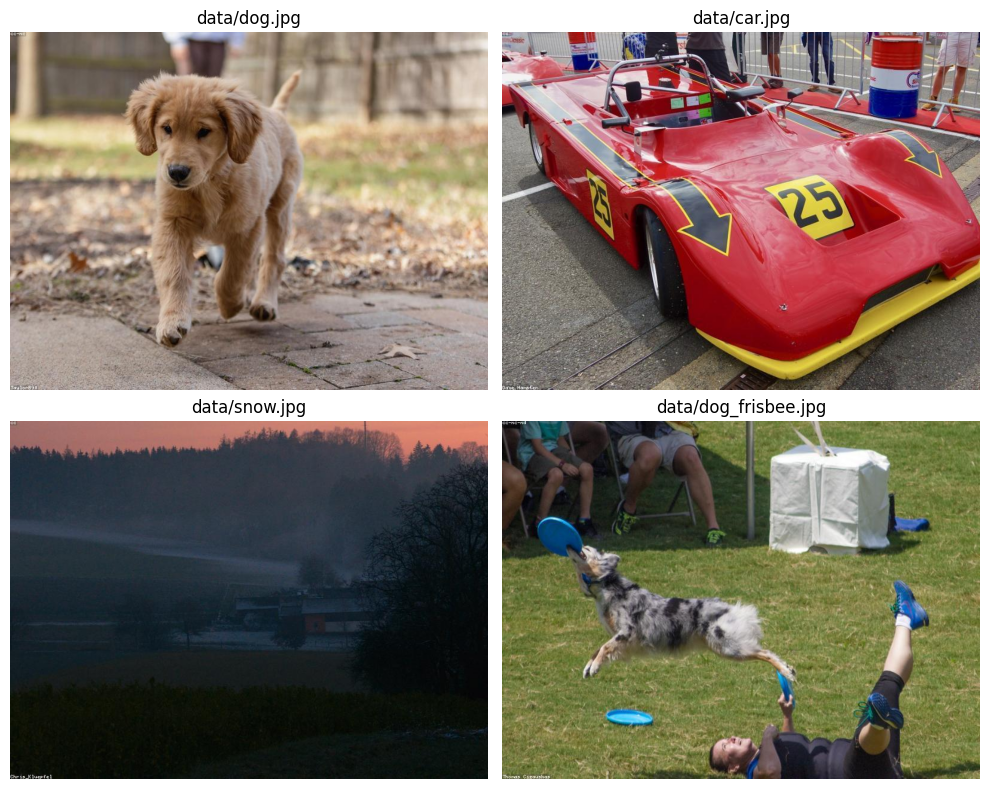

In [4]:
# visualize our public dataset images
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
image_paths = ['data/dog.jpg', 'data/car.jpg', 'data/snow.jpg', 'data/dog_frisbee.jpg']
for ax, img_name in zip(axes.flatten(), image_paths):
    img = Image.open(img_name)
    ax.imshow(img)
    ax.set_title(img_name)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 1. Zero-Shot Image Classification

Implement a function that takes an image and a list of text labels, and returns the index of the most likely label according to  highest softmax probability among the labels. The steps are approximately as follows:
- Obtain embeddings of images to be classified.
- Obtain embeddings of the class labels.
- Compute similarities between the images and the class labels.
- Obtain probabilites by applying softmax over the similarites (optional, as the fn is monotonic) and obtain predictions.

You are encouraged to read the CLIP paper (https://arxiv.org/abs/2103.00020) to understand this methodology more closely. Use `get_model()` to access the `model` and `processor`.


In [5]:
def zero_shot_classification(image: Image.Image, text_labels: list[str]) -> int:
    """
    Computes the cosine similarity between the image and each text label.
    Returns the index of the highest scoring text label.
    """
    model, processor = get_model()
    ####### CODE BELOW ############
    inputs = processor(text=text_labels, images=image, return_tensors="pt", padding=True)

    with torch.no_grad():
        outputs = model(**inputs)
        logits_per_image = outputs.logits_per_image

    probs = logits_per_image.softmax(dim=1)[0].numpy()
    return np.argmax(probs)
    ####### CODE ABOVE ############


### Visualizing Zero-Shot Probabilities
Let's see the model's confidence across the different labels visually!


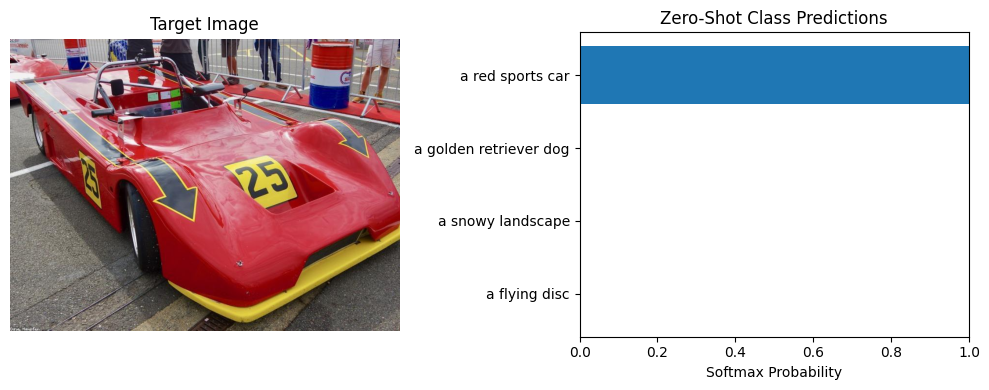

In [6]:
labels = ["a red sports car", "a golden retriever dog", "a snowy landscape", "a flying disc"]
img = Image.open('data/car.jpg')

# helper fn to extract the raw probabilities for visualization
model, processor = get_model()
inputs = processor(text=labels, images=img, return_tensors="pt", padding=True)
with torch.no_grad():
    outputs = model(**inputs)
probs = outputs.logits_per_image.softmax(dim=1)[0].numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(img)
ax1.axis('off')
ax1.set_title('Target Image')

y_pos = np.arange(len(labels))
ax2.barh(y_pos, probs, align='center')
ax2.set_yticks(y_pos, labels=labels)
ax2.invert_yaxis()  # labels read top-to-bottom
ax2.set_xlabel('Softmax Probability')
ax2.set_xlim(0, 1)
ax2.set_title('Zero-Shot Class Predictions')
plt.tight_layout()
plt.show()


## 2. Text-to-Image Retrieval

Implement a function that retrieves the most relevant image from a list of candidate images given a text query. Since the embedding cosine similarities imply semantic similarities, you may rank candidate images by normalized embedding similarity.


In [17]:
def text_to_image_retrieval(text_query: str, images: list[Image.Image]) -> int:
    """
    computes the similarity between the text query and each candidate image.
    returns the index of the most similar image in the list.
    """
    model, processor = get_model()
    ####### CODE BELOW ############
    inputs = processor(text=[text_query], images=images, return_tensors="pt", padding=True)

    with torch.no_grad():
        outputs = model(**inputs)
        logits_per_text = outputs.logits_per_text   # shape: (1, num_images)

    probs = logits_per_text.softmax(dim=1)[0].cpu().numpy()
    return int(np.argmax(probs))

    return np.argmax(probs)
    ####### CODE ABOVE ############


In [ ]:
# You are encouraged to write some basic tests here

### Visualizing Visual Search
Let's observe our Text-to-Image search algorithm in action.


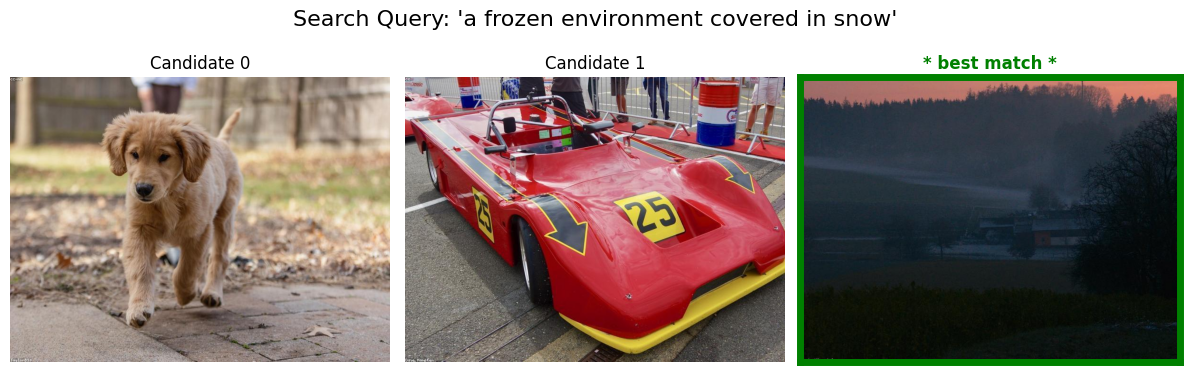

In [18]:
candidates = [Image.open('data/dog.jpg'), Image.open('data/car.jpg'), Image.open('data/snow.jpg')]
query = "a frozen environment covered in snow"

try:
    best_idx = text_to_image_retrieval(query, candidates)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"Search Query: '{query}'", fontsize=16)
    for i, ax in enumerate(axes):
        ax.imshow(candidates[i])
        ax.axis('off')
        if i == best_idx:
            ax.set_title("* best match *", color='green', fontweight='bold')
            # draw border on the correct
            for spine in ax.spines.values():
                spine.set_edgecolor('green')
                spine.set_linewidth(5)
            ax.axis('on')
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.set_title(f"Candidate {i}")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("implement text_to_image_retrieval to see the visuals plz")


## 3. Composed Image Retrieval

Composed image retrieval is a relatively new task defined by querying by a (query image, modification text) pair. Some of the [best papers ever](https://openaccess.thecvf.com/content/CVPR2025/papers/Xing_ConText-CIR_Learning_from_Concepts_in_Text_for_Composed_Image_Retrieval_CVPR_2025_paper.pdf) have been written about composed image retrival. In this task, you will implement a rudimentary model for composed image retrieval based on embedding interpolation. Given a source image, a text modification query, and an interpolation factor `alpha` $\in [0, 1]$, you will compute the modified embedding as:
`target_embed = (1 - alpha) * image_embed + alpha * text_embed`

Note that both the image and text embeddings should be normalized prior to interpolation.
You then rank a list of candidate images and return the index of the closest match (using cosine similarity between the candidate embeddings and the `target_embed`) as in the previous task.


In [47]:
def composed_image_retrieval(source_image: Image.Image, text_modifier: str, alpha: float, candidate_images: list[Image.Image]) -> int:
    """
    interpolates between L2 normalized source image embedding and L2 normalized text modifier embedding,
    returns the index of the closest candidate image.
    """
    import torch
    import torch.nn.functional as F
    model, processor = get_model()
    #get source image features
    img_inputs = processor(images=source_image, return_tensors="pt")
    with torch.no_grad():
        img_features = model.get_image_features(**img_inputs)

    # get text modifier features
    text_inputs = processor(text=[text_modifier], return_tensors="pt", padding=True)
    with torch.no_grad():
        text_features = model.get_text_features(**text_inputs)

    ####### CODE BELOW ############
    # turn outputs into CLIP embedding tensors
    img_features = img_features.pooler_output
    text_features = text_features.pooler_output

    img_features = F.normalize(img_features, p=2, dim=-1)
    text_features = F.normalize(text_features, p=2, dim=-1)

    target_embed = (1 - alpha) * img_features + alpha * text_features
    target_embed = F.normalize(target_embed, p=2, dim=-1)

    cand_inputs = processor(images=candidate_images, return_tensors="pt")
    with torch.no_grad():
        cand_outputs = model.get_image_features(**cand_inputs)

    cand_features = cand_outputs.pooler_output
    cand_features = F.normalize(cand_features, p=2, dim=-1)

    similarities = F.cosine_similarity(cand_features, target_embed, dim=-1)
    return similarities.argmax().item()
    ####### CODE ABOVE ############


In [ ]:
# You are encouraged to write some basic tests here

In [46]:
model, processor = get_model()

source = Image.open('data/dog.jpg')
img_inputs = processor(images=source, return_tensors="pt")
text_inputs = processor(text=["catching a blue frisbee"], return_tensors="pt", padding=True)

with torch.no_grad():
    img_out = model.get_image_features(**img_inputs)
    text_out = model.get_text_features(**text_inputs)

print(type(img_out))
print(type(text_out))
print(img_out.keys())
print(text_out.keys())
print(img_out.pooler_output.shape)
print(text_out.pooler_output.shape)

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
odict_keys(['last_hidden_state', 'pooler_output'])
odict_keys(['last_hidden_state', 'pooler_output'])
torch.Size([1, 512])
torch.Size([1, 512])


### Visualizing Composed Retrieval
Let's use the function you implemented on a real composed image retrieval query. We'll use the `[Dog Image]` + `Text("catching a blue frisbee")` pair.


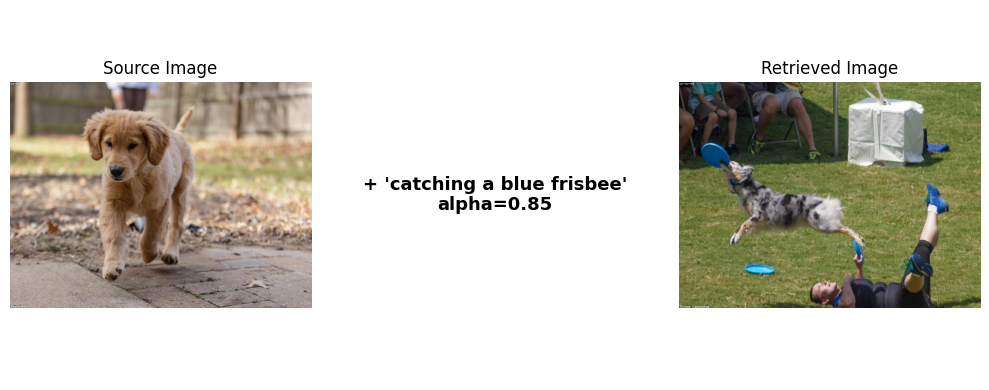

In [48]:
source = Image.open('data/dog.jpg')
modifier = "catching a blue frisbee"
candidates = [Image.open('data/dog.jpg'), Image.open('data/car.jpg'), Image.open('data/dog_frisbee.jpg')]
alpha = 0.85

try:
    best_idx = composed_image_retrieval(source, modifier, alpha, candidates)

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    axes[0].imshow(source)
    axes[0].set_title("Source Image")
    axes[0].axis('off')

    label = f"+ '{modifier}'\nalpha={alpha}"
    axes[1].text(0.5, 0.5, label, ha='center', va='center', fontsize=13, fontweight='bold', wrap=True)
    axes[1].axis('off')

    axes[2].imshow(candidates[best_idx])
    axes[2].set_title("Retrieved Image")
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'{e}')
    print("Implement composed_image_retrieval to see the visualization!")


## 4. Cross-Modal Similarity Matrix

Finally, write a function that takes a list of $N$ images and $M$ texts, and returns a PyTorch Tensor of shape $(N, M)$ representing the pairwise cosine similarities between every image and every text.
Return the raw cosine similarity scores, not probabilities. Use the standard normalized representations from CLIP.


In [49]:
def cross_modal_similarity(images: list[Image.Image], texts: list[str]) -> torch.Tensor:
    """
    Should compute the pairwise cosine similarity between the normalized representations N images and M texts.
    Returns:
        Tensor of shape (N, M)
    """
    model, processor = get_model()
    ####### CODE BELOW ############
    img_inputs = processor(images=images, return_tensors="pt")
    text_inputs = processor(text=texts, return_tensors="pt", padding=True)
    with torch.no_grad():
        img_features = model.get_image_features(**img_inputs)
        text_features = model.get_text_features(**text_inputs)

    img_features = F.normalize(img_features.pooler_output, p=2, dim=-1)
    text_features = F.normalize(text_features.pooler_output, p=2, dim=-1)
    similarities = F.cosine_similarity(img_features.unsqueeze(1), text_features.unsqueeze(0), dim=-1)
    return similarities
    ####### CODE ABOVE ############


In [ ]:
# You are encouraged to write some basic tests here

### Visualizing the Semantic Space
Let's investigate how the specific attributes of these images fire against a wider variety of prompts by viewing the similarity matrix as a heatmap. We'll use the function you implemented.


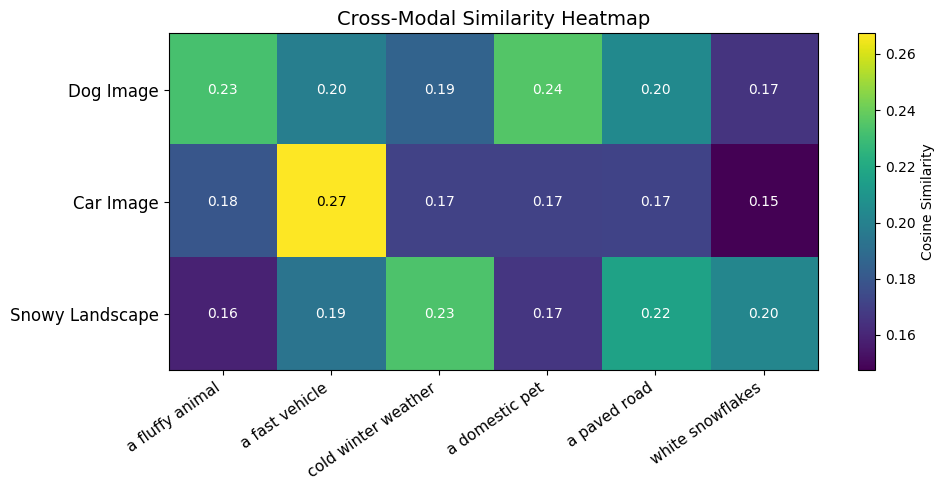

In [50]:
images = [Image.open('data/dog.jpg'), Image.open('data/car.jpg'), Image.open('data/snow.jpg')]
image_labels = ['Dog Image', 'Car Image', 'Snowy Landscape']
texts = [
    "a fluffy animal",
    "a fast vehicle",
    "cold winter weather",
    "a domestic pet",
    "a paved road",
    "white snowflakes"
]

try:
    sim_matrix = cross_modal_similarity(images, texts).numpy()

    plt.figure(figsize=(10, 5))
    plt.imshow(sim_matrix, cmap='viridis', aspect='auto')
    plt.colorbar(label='Cosine Similarity')

    # annotate da values
    for i in range(len(images)):
        for j in range(len(texts)):
            plt.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center", color="white" if sim_matrix[i, j] < sim_matrix.max()*0.9 else "black")

    plt.xticks(range(len(texts)), texts, rotation=35, ha='right', fontsize=11)
    plt.yticks(range(len(images)), image_labels, fontsize=12)
    plt.title("Cross-Modal Similarity Heatmap", fontsize=14)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("implement cross_modal_similarity to see the visualization!")
